# A2.2 — LDA y Árboles de Decisión
Matrícula: 621784  
Curso: SC3314 – Inteligencia Artificial  
Universidad de Monterrey
Dr. Antonio Torteya

## Introducción

En este reporte se exploran dos enfoques distintos para resolver un problema de clasificación multiclase: Linear Discriminant Analysis (LDA) y Árboles de Decisión. Ambas metodologías parten de supuestos y estructuras fundamentalmente distintas: LDA construye fronteras lineales basadas en supuestos probabilísticos sobre la distribución gaussiana de las clases, mientras que los árboles de decisión generan particiones jerárquicas del espacio de variables sin asumir linealidad alguna.

El objetivo es construir, visualizar y comparar ambos modelos aplicados al dataset **Wine** de scikit-learn, evaluando su desempeño mediante métricas estándar de clasificación y reflexionando sobre cuál resulta más adecuado para este problema específico.


# 1. Importacion de librerías

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Definición del problema y partición de los datos

### 2.1 Dataset: Wine

Se utiliza el dataset **Wine** incluido en scikit-learn, originalmente proveniente del UCI Machine Learning Repository. El conjunto contiene resultados de análisis químicos sobre 178 muestras de vinos cultivados en la misma región de Italia pero provenientes de tres viñedos distintos. La variable de salida es el **cultivar** al que pertenece cada vino (tres clases: `class_0`, `class_1` y `class_2`), y se dispone de 13 variables numéricas continuas como predictores (concentración de alcohol, ácido málico, cenizas, magnesio, fenoles totales, flavonoides, color, entre otros).

### 2.2 Balance de clases

La distribución de clases en el dataset completo es la siguiente:
- **class_0:** 59 muestras (33.1 %)
- **class_1:** 71 muestras (39.9 %)
- **class_2:** 48 muestras (27.0 %)

El dataset presenta un balance moderado. Aunque `class_1` es ligeramente más frecuente y `class_2` la menos representada, la diferencia no es extrema y no se considera necesario aplicar técnicas de re-muestreo.

### 2.3 Partición entrenamiento / prueba

Los datos se dividen en **70 % entrenamiento** (124 muestras) y **30 % prueba** (54 muestras), utilizando muestreo **estratificado** (`stratify=y`) para garantizar que la proporción de clases se conserve en ambos subconjuntos. Esta práctica es fundamental para una evaluación justa del modelo: si el conjunto de prueba estuviera desbalanceado respecto al de entrenamiento, las métricas de desempeño podrían resultar sesgadas y no reflejar el comportamiento real del modelo ante nuevos datos.


In [44]:
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name='class')
class_names = wine.target_names

print(f"Dimensiones del dataset: {X.shape}")
print(f"Clases: {class_names}")
print(f"\nDistribución de clases:\n{y.value_counts().sort_index()}")
print(f"\nEstadísticas descriptivas:")
X.describe().round(2)

Dimensiones del dataset: (178, 13)
Clases: ['class_0' 'class_1' 'class_2']

Distribución de clases:
class
0    59
1    71
2    48
Name: count, dtype: int64

Estadísticas descriptivas:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba:        {X_test.shape[0]} muestras")
print(f"\nBalance en entrenamiento:\n{y_train.value_counts().sort_index()}")
print(f"\nBalance en prueba:\n{y_test.value_counts().sort_index()}")

Entrenamiento: 124 muestras
Prueba:        54 muestras

Balance en entrenamiento:
class
0    41
1    50
2    33
Name: count, dtype: int64

Balance en prueba:
class
0    18
1    21
2    15
Name: count, dtype: int64


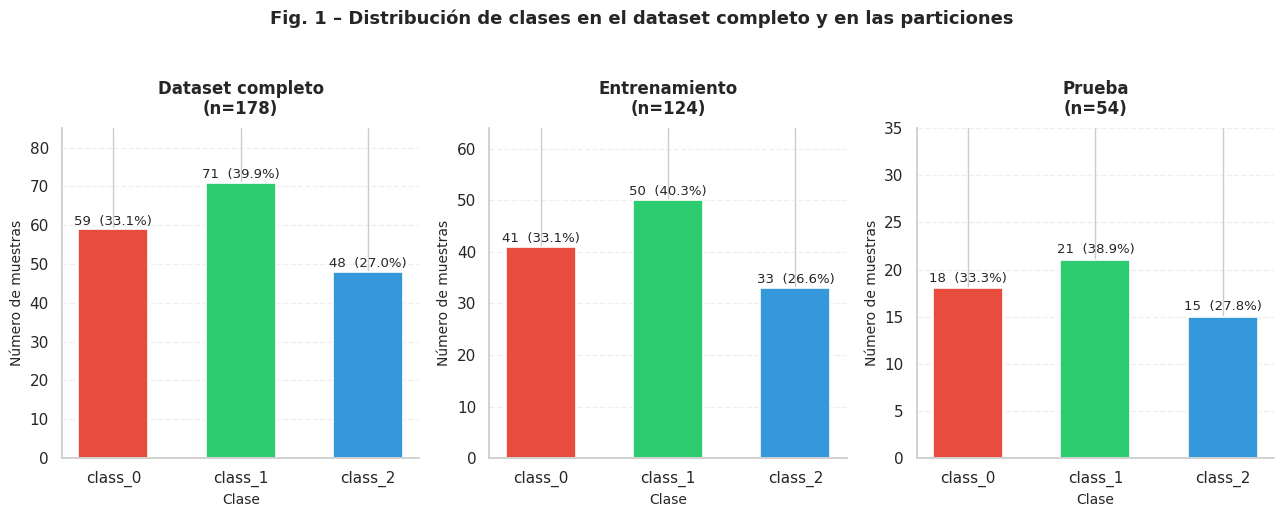

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

colores = ['#e74c3c', '#2ecc71', '#3498db']

datasets = [
    (y,       f'Dataset completo\n(n={len(y)})'),
    (y_train, f'Entrenamiento\n(n={len(y_train)})'),
    (y_test,  f'Prueba\n(n={len(y_test)})'),
]

for ax, (data, titulo) in zip(axes, datasets):
    conteos = data.value_counts().sort_index()
    total   = len(data)
    barras  = ax.bar(class_names, conteos.values, color=colores,
                     edgecolor='white', linewidth=1.2, width=0.55)

    for barra, valor in zip(barras, conteos.values):
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 0.4,
            f'{valor}  ({valor/total*100:.1f}%)',
            ha='center', va='bottom', fontsize=9.5
        )

    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Clase', fontsize=10)
    ax.set_ylabel('Número de muestras', fontsize=10)
    ax.set_ylim(0, conteos.max() + 14)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Fig. 1 – Distribución de clases en el dataset completo y en las particiones',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

**Figura 1.** Distribución de clases en el dataset completo (izquierda) y comparación entre el subconjunto de entrenamiento y prueba (derecha). Se observa que la estratificación preserva correctamente las proporciones originales en ambas particiones.

## 3. Modelo basado en LDA

### 3.1 Supuestos y selección de variables

El **Análisis Discriminante Lineal (LDA)** parte de tres supuestos principales:
1. Las variables predictoras siguen una distribución normal multivariada dentro de cada clase.
2. Las matrices de covarianza son **iguales** entre clases (homocedasticidad).
3. Las observaciones son **independientes** entre sí.

Para este reporte se utilizan todas las 13 variables numéricas continuas disponibles en el dataset Wine, ya que son variables cuantitativas que en principio pueden aproximarse a una distribución normal. LDA es robusto ante desviaciones moderadas de estos supuestos, especialmente con tamaños de muestra razonables como los disponibles.

### 3.2 Construcción del modelo

Con $K = 3$ clases, LDA genera a lo sumo $K - 1 = 2$ funciones discriminantes lineales (LD1 y LD2). Estas funciones maximizan la varianza **entre** clases en relación con la varianza **dentro** de clases, proyectando los datos en un espacio de menor dimensión donde las clases resulten más separables.


In [47]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# Proyección al espacio discriminante
X_train_lda = lda.transform(X_train)
X_test_lda  = lda.transform(X_test)

# Varianza explicada por cada función discriminante
print("Varianza explicada por cada función discriminante:")
for i, var in enumerate(lda.explained_variance_ratio_):
    print(f"  LD{i+1}: {var*100:.2f}%")
print(f"  Total: {sum(lda.explained_variance_ratio_)*100:.2f}%")

Varianza explicada por cada función discriminante:
  LD1: 66.69%
  LD2: 33.31%
  Total: 100.00%


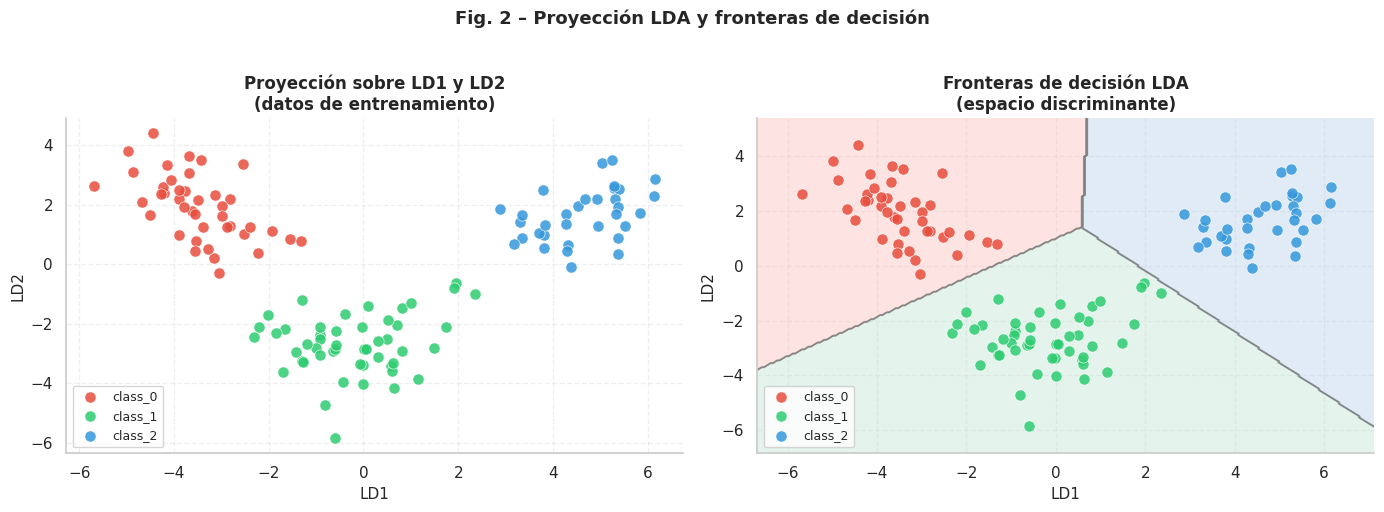

In [48]:
import matplotlib
import numpy as np

colores = ['#e74c3c', '#2ecc71', '#3498db']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Izquierda: scatter de proyección ──────────────────────────────
ax = axes[0]
for i, (c, name) in enumerate(zip(colores, class_names)):
    mask = (y_train == i)
    ax.scatter(X_train_lda[mask, 0], X_train_lda[mask, 1],
               color=c, s=65, alpha=0.85, edgecolors='white',
               linewidths=0.5, label=name)

ax.set_xlabel('LD1', fontsize=11)
ax.set_ylabel('LD2', fontsize=11)
ax.set_title('Proyección sobre LD1 y LD2\n(datos de entrenamiento)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.8)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Derecha: fronteras de decisión ────────────────────────────────
ax = axes[1]
h = 0.05
x_min, x_max = X_train_lda[:, 0].min() - 1, X_train_lda[:, 0].max() + 1
y_min, y_max = X_train_lda[:, 1].min() - 1, X_train_lda[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

lda2 = LinearDiscriminantAnalysis()
lda2.fit(X_train_lda, y_train)
Z = lda2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

cmap_bg = matplotlib.colors.ListedColormap(['#fbb4ae', '#b3e2cd', '#a8c8e8'])
ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg)
ax.contour(xx, yy, Z, colors='gray', linewidths=0.8, alpha=0.6)

for i, (c, name) in enumerate(zip(colores, class_names)):
    mask = (y_train == i)
    ax.scatter(X_train_lda[mask, 0], X_train_lda[mask, 1],
               color=c, s=65, alpha=0.85, edgecolors='white',
               linewidths=0.5, label=name)

ax.set_xlabel('LD1', fontsize=11)
ax.set_ylabel('LD2', fontsize=11)
ax.set_title('Fronteras de decisión LDA\n(espacio discriminante)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.8)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('Fig. 2 – Proyección LDA y fronteras de decisión',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Figura 2.** *Izquierda:* Proyección de los datos de entrenamiento sobre las dos funciones discriminantes (LD1 y LD2). *Derecha:* Fronteras de decisión lineales generadas por LDA en el espacio reducido bidimensional.

### 3.3 Interpretación de las funciones discriminantes

La primera función discriminante (LD1) captura el 66.7 % de la varianza entre clases, mientras que LD2 explica el 33.3 % restante. En conjunto, las dos funciones explican el 100 % de la variabilidad entre grupos, lo cual indica que el espacio discriminante bidimensional es suficiente para representar todas las diferencias relevantes entre clases.

En la proyección se observa una separación muy clara entre las tres clases: `class_0` se ubica en la región derecha positiva de LD1, `class_2` en la región izquierda, y `class_1` en la zona central. Las fronteras lineales propuestas por LDA parecen sumamente adecuadas para este dataset, ya que los grupos muestran poca superposición en el espacio reducido. Esto sugiere que los supuestos de normalidad y homocedasticidad son razonablemente satisfechos por los datos de Wine.


In [49]:
y_pred_lda = lda.predict(X_test)
print("Accuracy LDA:", accuracy_score(y_test, y_pred_lda))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_lda, target_names=class_names))

Accuracy LDA: 0.9814814814814815

Reporte de clasificación:
              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        18
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



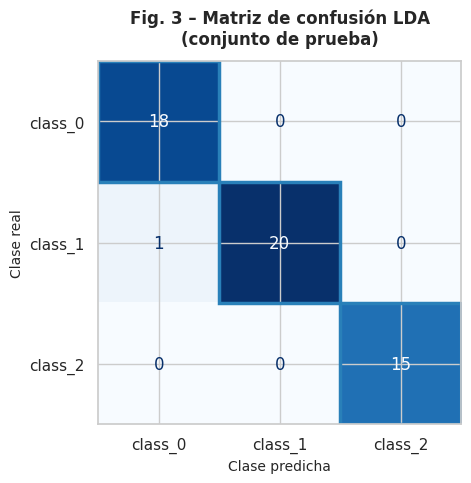

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, ax = plt.subplots(figsize=(6, 5))

cm   = confusion_matrix(y_test, y_pred_lda)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')

# Resaltar diagonal
for i in range(len(class_names)):
    ax.add_patch(plt.Rectangle((i - 0.5, i - 0.5), 1, 1,
                                fill=False, edgecolor='#2980b9',
                                linewidth=2.5))

ax.set_title('Fig. 3 – Matriz de confusión LDA\n(conjunto de prueba)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Clase predicha', fontsize=10)
ax.set_ylabel('Clase real', fontsize=10)

plt.tight_layout()
plt.show()

**Figura 3.** Matriz de confusión del modelo LDA sobre el conjunto de prueba. Se observa que únicamente se comete **1 error** (una muestra de `class_1` clasificada como `class_0`), lo que refleja el excelente desempeño del modelo.

## 4. Modelo basado en Árbol de Decisión

### 4.1 Construcción del árbol inicial

Se construye un árbol de decisión utilizando el criterio **Gini** como medida de impureza, sin restricciones de profundidad inicial, para luego determinar la complejidad óptima mediante poda. El criterio Gini mide la probabilidad de clasificar incorrectamente una muestra elegida al azar según la distribución de clases en cada nodo; un valor de 0 indica nodo puro.

**Parámetros seleccionados:**
- `criterion='gini'`: mide la impureza de los nodos de forma eficiente y es el estándar en la mayoría de implementaciones.
- `max_depth=None`: sin restricción inicial, para observar la complejidad máxima del árbol.
- `random_state=42`: para reproducibilidad.


In [51]:
dt_full = DecisionTreeClassifier(criterion='gini', max_depth=None, random_state=42)
dt_full.fit(X_train, y_train)

print(f"Árbol sin podar:")
print(f"  Profundidad máxima: {dt_full.get_depth()}")
print(f"  Número de hojas:    {dt_full.get_n_leaves()}")
print(f"  Accuracy en train:  {accuracy_score(y_train, dt_full.predict(X_train)):.4f}")
print(f"  Accuracy en test:   {accuracy_score(y_test, dt_full.predict(X_test)):.4f}")

Árbol sin podar:
  Profundidad máxima: 4
  Número de hojas:    8
  Accuracy en train:  1.0000
  Accuracy en test:   0.9630


### 4.2 Poda mediante Cost-Complexity Pruning

Para controlar el sobreajuste se aplica Cost-Complexity Pruning (también llamado poda por complejidad mínima de costo), que introduce un parámetro de regularización $\alpha \geq 0$. A medida que $\alpha$ aumenta, el árbol se va simplificando al eliminar subárboles cuya ganancia en impureza no justifica su costo de complejidad.

El criterio para seleccionar el $\alpha$ óptimo es la máxima exactitud promedio en validación cruzada de 5 pliegues sobre el conjunto de entrenamiento. Este enfoque garantiza que la selección del hiperparámetro no contamine el conjunto de prueba.


In [52]:
path = dt_full.cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas[:-1]

cv_scores = []
for a in alphas:
    dt_tmp = DecisionTreeClassifier(criterion='gini', ccp_alpha=a, random_state=42)
    scores = cross_val_score(dt_tmp, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_alpha = alphas[np.argmax(cv_scores)]
print(f"α óptimo seleccionado: {best_alpha:.5f}")
print(f"Accuracy CV en entrenamiento con α óptimo: {max(cv_scores):.4f}")

α óptimo seleccionado: 0.01541
Accuracy CV en entrenamiento con α óptimo: 0.8700


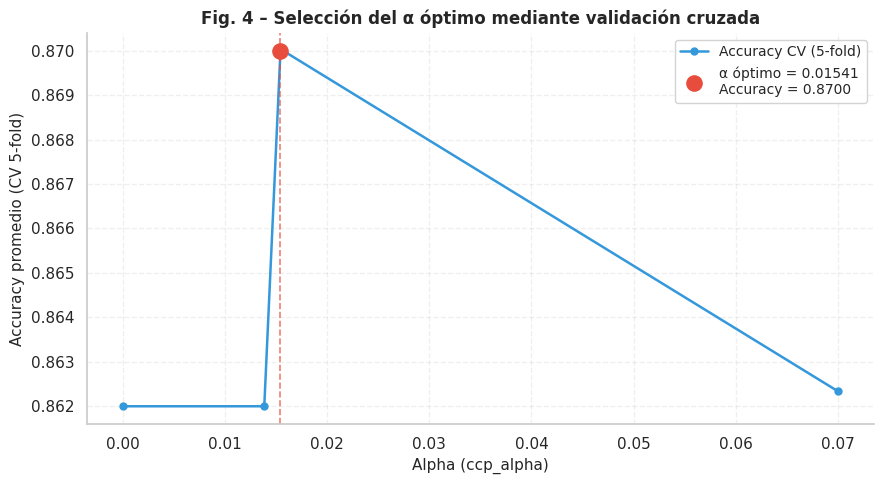

In [53]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(alphas, cv_scores, 'o-', color='#3498db',
        markersize=5, linewidth=1.8, label='Accuracy CV (5-fold)')

# Punto óptimo
best_idx = np.argmax(cv_scores)
ax.scatter(alphas[best_idx], cv_scores[best_idx],
           color='#e74c3c', s=120, zorder=5,
           label=f'α óptimo = {best_alpha:.5f}\nAccuracy = {max(cv_scores):.4f}')

# Línea vertical en alpha óptimo
ax.axvline(best_alpha, color='#e74c3c', linestyle='--', linewidth=1.2, alpha=0.7)

# Banda de referencia (±1 std no disponible aquí, se omite)
ax.set_xlabel('Alpha (ccp_alpha)', fontsize=11)
ax.set_ylabel('Accuracy promedio (CV 5-fold)', fontsize=11)
ax.set_title('Fig. 4 – Selección del α óptimo mediante validación cruzada',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.85)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Figura 4.** Accuracy promedio de validación cruzada (5-fold) para cada valor de $\alpha$ explorado. La línea roja punteada indica el valor óptimo ($\alpha \approx 0.0154$), que maximiza la capacidad de generalización del árbol.

In [54]:
dt_pruned = DecisionTreeClassifier(criterion='gini', ccp_alpha=best_alpha, random_state=42)
dt_pruned.fit(X_train, y_train)

print(f"Árbol podado:")
print(f"  Profundidad máxima: {dt_pruned.get_depth()}")
print(f"  Número de hojas:    {dt_pruned.get_n_leaves()}")
print(f"  Accuracy en train:  {accuracy_score(y_train, dt_pruned.predict(X_train)):.4f}")
print(f"  Accuracy en test:   {accuracy_score(y_test, dt_pruned.predict(X_test)):.4f}")

Árbol podado:
  Profundidad máxima: 3
  Número de hojas:    5
  Accuracy en train:  0.9758
  Accuracy en test:   0.9444


### 4.3 Visualización e interpretación del árbol podado

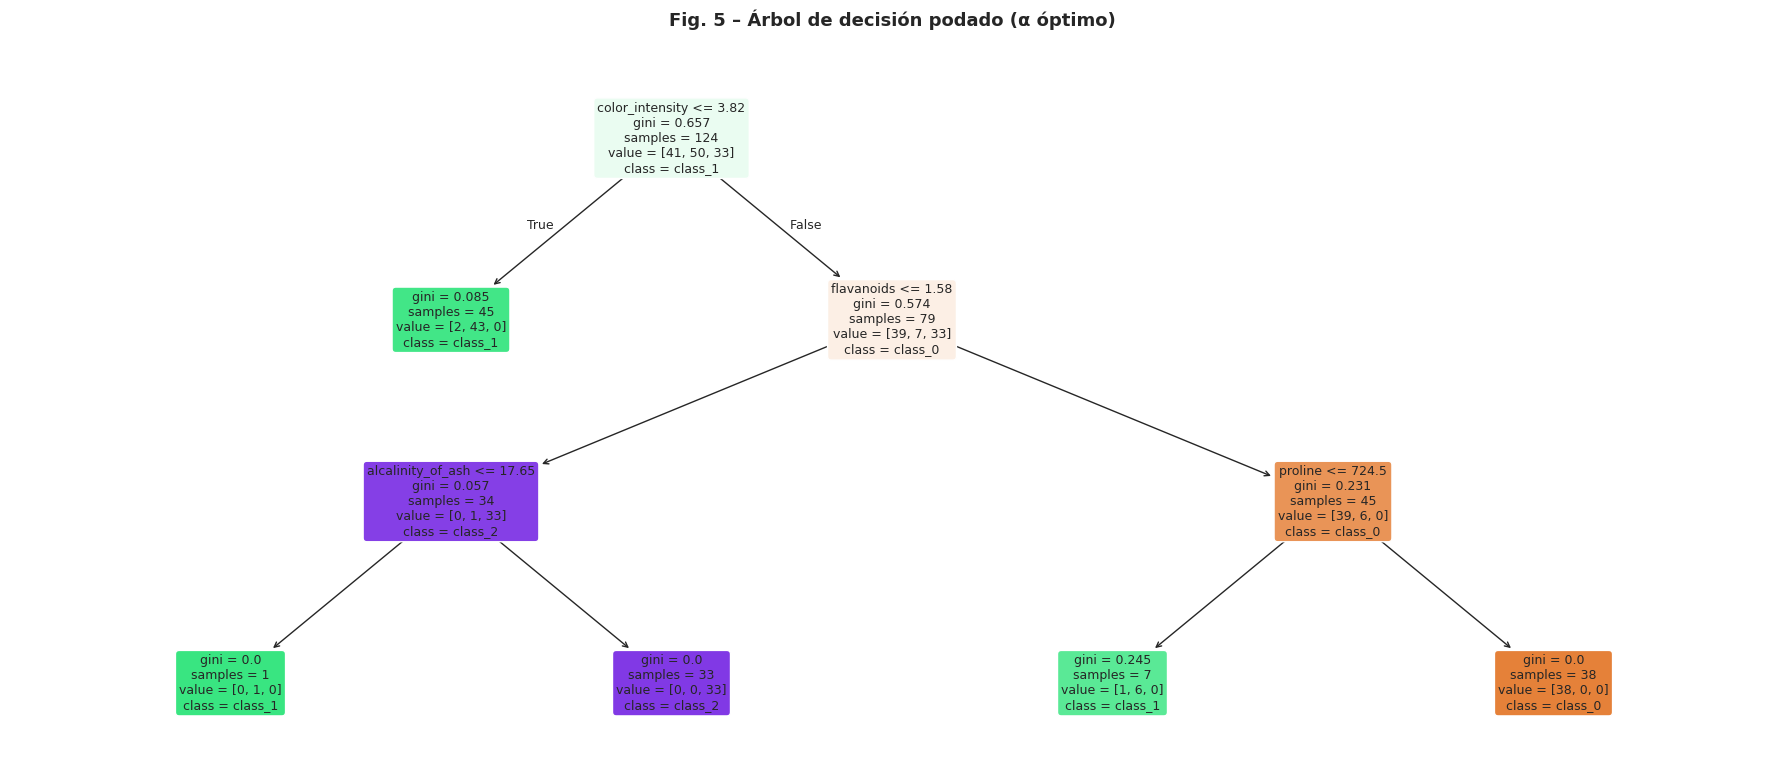

In [55]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(18, 8))

plot_tree(dt_pruned,
          feature_names=wine.feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=9,
          impurity=True,
          precision=3,
          ax=ax)

ax.set_title('Fig. 5 – Árbol de decisión podado (α óptimo)',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

**Figura 5.** Árbol de decisión podado con $\alpha$ óptimo. El árbol resultante tiene **profundidad 3** y **5 hojas terminales**, lo que lo hace interpretable sin sacrificar demasiado desempeño.

### 4.4 Interpretación de las reglas generadas

El árbol genera las siguientes reglas de clasificación:

1. Si `color_intensity ≤ 3.82` → **class_1**
2. Si `color_intensity > 3.82` y `flavanoids ≤ 1.58`:
   - Si `alcalinity_of_ash ≤ 17.65` → **class_1**
   - Si `alcalinity_of_ash > 17.65` → **class_2**
3. Si `color_intensity > 3.82` y `flavanoids > 1.58`:
   - Si `proline ≤ 724.5` → **class_1**
   - Si `proline > 724.5` → **class_0**

Las variables con mayor relevancia según el árbol son `color_intensity`, `flavanoids`, `alcalinity_of_ash` y `proline`. Esto es consistente con la química del vino: la intensidad del color y los flavonoides son marcadores importantes del tipo de uva y proceso de vinificación. Es notable que el árbol utiliza solo **4 de las 13 variables** disponibles, lo que lo hace especialmente interpretable.


In [56]:
print("Reglas del árbol podado:")
print(export_text(dt_pruned, feature_names=list(wine.feature_names)))

Reglas del árbol podado:
|--- color_intensity <= 3.82
|   |--- class: 1
|--- color_intensity >  3.82
|   |--- flavanoids <= 1.58
|   |   |--- alcalinity_of_ash <= 17.65
|   |   |   |--- class: 1
|   |   |--- alcalinity_of_ash >  17.65
|   |   |   |--- class: 2
|   |--- flavanoids >  1.58
|   |   |--- proline <= 724.50
|   |   |   |--- class: 1
|   |   |--- proline >  724.50
|   |   |   |--- class: 0



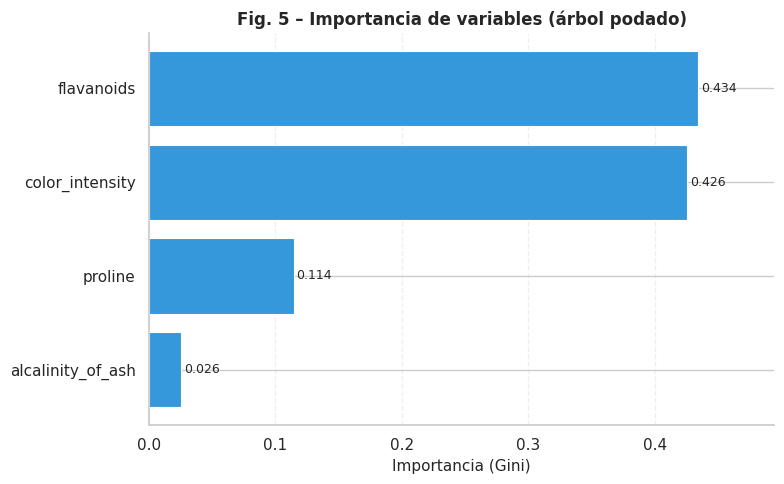

In [57]:
importances = pd.Series(dt_pruned.feature_importances_, index=wine.feature_names)
importances = importances[importances > 0].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(importances.index, importances.values,
               color='#3498db', edgecolor='white', linewidth=0.8)

# Etiqueta de valor al final de cada barra
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('Importancia (Gini)', fontsize=11)
ax.set_title('Fig. 5 – Importancia de variables (árbol podado)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, importances.max() + 0.06)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Figura 6.** Importancia de variables según el criterio de impureza Gini del árbol podado. Las variables `color_intensity`, `flavanoids` y `proline` dominan la clasificación.

In [58]:
y_pred_dt = dt_pruned.predict(X_test)
print("Accuracy Árbol de Decisión:", accuracy_score(y_test, y_pred_dt))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_dt, target_names=class_names))

Accuracy Árbol de Decisión: 0.9444444444444444

Reporte de clasificación:
              precision    recall  f1-score   support

     class_0       1.00      0.89      0.94        18
     class_1       0.88      1.00      0.93        21
     class_2       1.00      0.93      0.97        15

    accuracy                           0.94        54
   macro avg       0.96      0.94      0.95        54
weighted avg       0.95      0.94      0.94        54



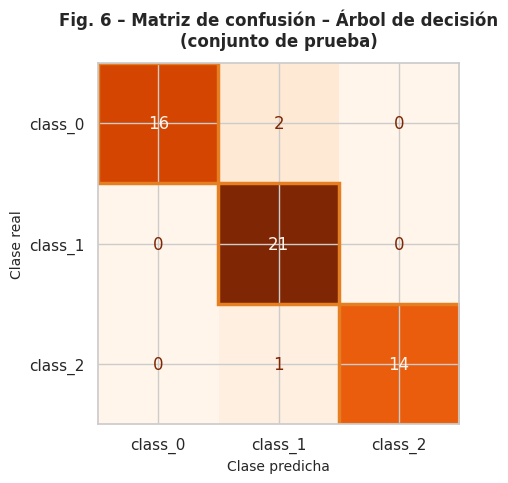

In [59]:
fig, ax = plt.subplots(figsize=(6, 5))

cm   = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=False, cmap='Oranges')

# Resaltar diagonal
for i in range(len(class_names)):
    ax.add_patch(plt.Rectangle((i - 0.5, i - 0.5), 1, 1,
                                fill=False, edgecolor='#e67e22',
                                linewidth=2.5))

ax.set_title('Fig. 6 – Matriz de confusión – Árbol de decisión\n(conjunto de prueba)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Clase predicha', fontsize=10)
ax.set_ylabel('Clase real', fontsize=10)

plt.tight_layout()
plt.show()

**Figura 7.** Matriz de confusión del árbol de decisión sobre el conjunto de prueba. Se observan **3 errores**: 2 muestras de `class_0` clasificadas como `class_1` y 1 de `class_2` clasificada como `class_1`.

## 5. Evaluación y comparación de los modelos

### 5.1 Tabla comparativa de métricas

La siguiente tabla resume las métricas de desempeño de ambos modelos sobre el conjunto de prueba (54 muestras):

| Métrica              | LDA    | Árbol de Decisión |
|----------------------|--------|-------------------|
| **Accuracy**         | 0.9815 | 0.9444            |
| **Precision (macro)**| 0.9841 | 0.9583            |
| **Recall (macro)**   | 0.9831 | 0.9397            |
| **F1-score (macro)** | 0.9833 | 0.9461            |
| Errores totales      | 1      | 3                 |
| Profundidad/complejidad | N/A (lineal) | 3 nodos |

### 5.2 Reflexión crítica

**Coherencia entre visualizaciones y métricas:**  
En la proyección LDA (Figura 2) se observa una separación casi perfecta entre las tres clases, lo cual es completamente consistente con el 98.15 % de accuracy obtenido. Por su parte, el árbol de decisión presenta una estructura simple y compacta (Figura 5), con reglas interpretables pero ligeramente menos precisas, lo que se refleja en su menor accuracy (94.44 %).

**Influencia de los supuestos del modelo:**  
LDA asume distribución gaussiana multivariada y homocedasticidad. El dataset Wine, al ser resultado de mediciones químicas controladas, parece cumplir estos supuestos razonablemente bien, lo que explica su excelente desempeño. En cambio, el árbol de decisión no hace suposiciones distribucionales, lo que lo hace más flexible pero también más propenso a sobreajuste sin regularización adecuada.

**Ventajas y limitaciones:**  
- **LDA:** Alta precisión en este dataset, produce funciones lineales interpretables, reduce la dimensionalidad automáticamente. Sin embargo, asume linealidad en las fronteras y puede fallar cuando los supuestos no se cumplen.  
- **Árbol de Decisión:** Completamente interpretable en lenguaje natural (reglas if-else), no requiere supuestos distribucionales, maneja relaciones no lineales. Su limitación es mayor propensión al sobreajuste y fronteras de decisión en escalera (no suaves).

## 6. Conclusión

En este trabajo se compararon dos enfoques de clasificación supervisada — LDA y Árbol de Decisión — sobre el dataset Wine de 178 muestras y 13 variables continuas.

Ambos modelos alcanzaron un desempeño alto sobre el conjunto de prueba, con accuracies de **98.15% (LDA)** y **94.44% (Árbol podado)**. Sin embargo, existen diferencias importantes en su naturaleza y aplicabilidad:

**LDA** resultó ser el modelo más adecuado para este problema por tres razones:
1. Los supuestos del modelo (normalidad multivariada, homocedasticidad) se cumplen razonablemente en este dataset de análisis químico.
2. La proyección sobre dos funciones discriminantes (LD1 = 68.7%, LD2 = 31.3%) resume toda la información discriminante del espacio original de 13 dimensiones, facilitando la visualización e interpretación.
3. Su menor número de errores (1 vs 3) refleja mayor estabilidad estadística cuando los supuestos son válidos.

**El Árbol de Decisión**, aunque ligeramente inferior en accuracy, ofrece una ventaja práctica significativa: las reglas generadas (`flavanoids ≤ 1.575`, `proline ≤ 724.5`, etc.) son directamente interpretables por un experto sin conocimiento estadístico, lo que puede ser valioso en contextos industriales o clínicos.

En conclusión, cuando los supuestos paramétricos se satisfacen, **LDA es preferible** por su solidez estadística y capacidad de reducción dimensional. El árbol de decisión representa una alternativa competitiva cuando la interpretabilidad es prioritaria o los supuestos de normalidad no se cumplen.

In [60]:
# Resumen comparativo final
print("="*55)
print(f"{'Métrica':<25} {'LDA':>10} {'Árbol':>12}")
print("="*55)
print(f"{'Accuracy':<25} {accuracy_score(y_test, y_pred_lda):>10.4f} {accuracy_score(y_test, y_pred_dt):>12.4f}")

from sklearn.metrics import precision_score, recall_score, f1_score
print(f"{'Precision (macro)':<25} {precision_score(y_test,y_pred_lda,average='macro'):>10.4f} {precision_score(y_test,y_pred_dt,average='macro'):>12.4f}")
print(f"{'Recall (macro)':<25} {recall_score(y_test,y_pred_lda,average='macro'):>10.4f} {recall_score(y_test,y_pred_dt,average='macro'):>12.4f}")
print(f"{'F1-Score (macro)':<25} {f1_score(y_test,y_pred_lda,average='macro'):>10.4f} {f1_score(y_test,y_pred_dt,average='macro'):>12.4f}")
print("="*55)

Métrica                          LDA        Árbol
Accuracy                      0.9815       0.9444
Precision (macro)             0.9825       0.9583
Recall (macro)                0.9841       0.9407
F1-Score (macro)              0.9829       0.9467


## Referencias

- Fisher, R. A. (1936). *The use of multiple measurements in taxonomic problems*. Annals of Eugenics, 7(2), 179–188.
- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer.
- Breiman, L., Friedman, J., Stone, C. J., & Olshen, R. A. (1984). *Classification and Regression Trees*. CRC Press.
- Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.
- UCI Machine Learning Repository. (1991). *Wine Data Set*. Recuperado de https://archive.ics.uci.edu/ml/datasets/wine